In [349]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import math

np.random.seed(11)
n = 25

Случайная величина имеет экспоненциальный закон распределения

```
p(x) = exp(-x){[0, inf)}
```

Сгенерируем выборку объёма `n = 25`

In [350]:
x_25 = np.random.exponential(scale=1, size=n)
x_25_s = np.round(x_25, 3)
print("Сгенерированная выборка:", x_25_s)

x_25 = np.sort(x_25)
print("Вариационный ряд:", np.sort(x_25_s))

Сгенерированная выборка: [0.199 0.02  0.622 1.291 0.545 0.664 0.013 0.668 2.844 1.902 1.309 0.115
 2.243 1.946 0.18  1.001 0.021 0.124 0.38  0.172 1.423 1.705 0.423 0.384
 0.118]
Вариационный ряд: [0.013 0.02  0.021 0.115 0.118 0.124 0.172 0.18  0.199 0.38  0.384 0.423
 0.545 0.622 0.664 0.668 1.001 1.291 1.309 1.423 1.705 1.902 1.946 2.243
 2.844]


## a)

In [351]:
l = x_25[-1] - x_25[0]

print(f"Непрерывное распределение. Все элементы выборки являются модой.")
print(f"Медиана: {np.round(np.median(x_25), 3)}")
print(f"Размах: {np.round(l, 3)}")
print(f"Среднее: {np.round(np.mean(x_25), 3)}")

Непрерывное распределение. Все элементы выборки являются модой.
Медиана: 0.545
Размах: 2.831
Среднее: 0.813


In [352]:
def c_Mk(n:int, k:int, x:np.array):
    return np.sum((x - np.mean(x))**k)/n

skewness = c_Mk(n, 3, x_25)/c_Mk(n, 2, x_25)**(3/2)
print(f"Коэффициент асимметрии: {np.round(skewness, 3)}")

Коэффициент асимметрии: 0.959


## b)

### Эмпирическая функция распредления

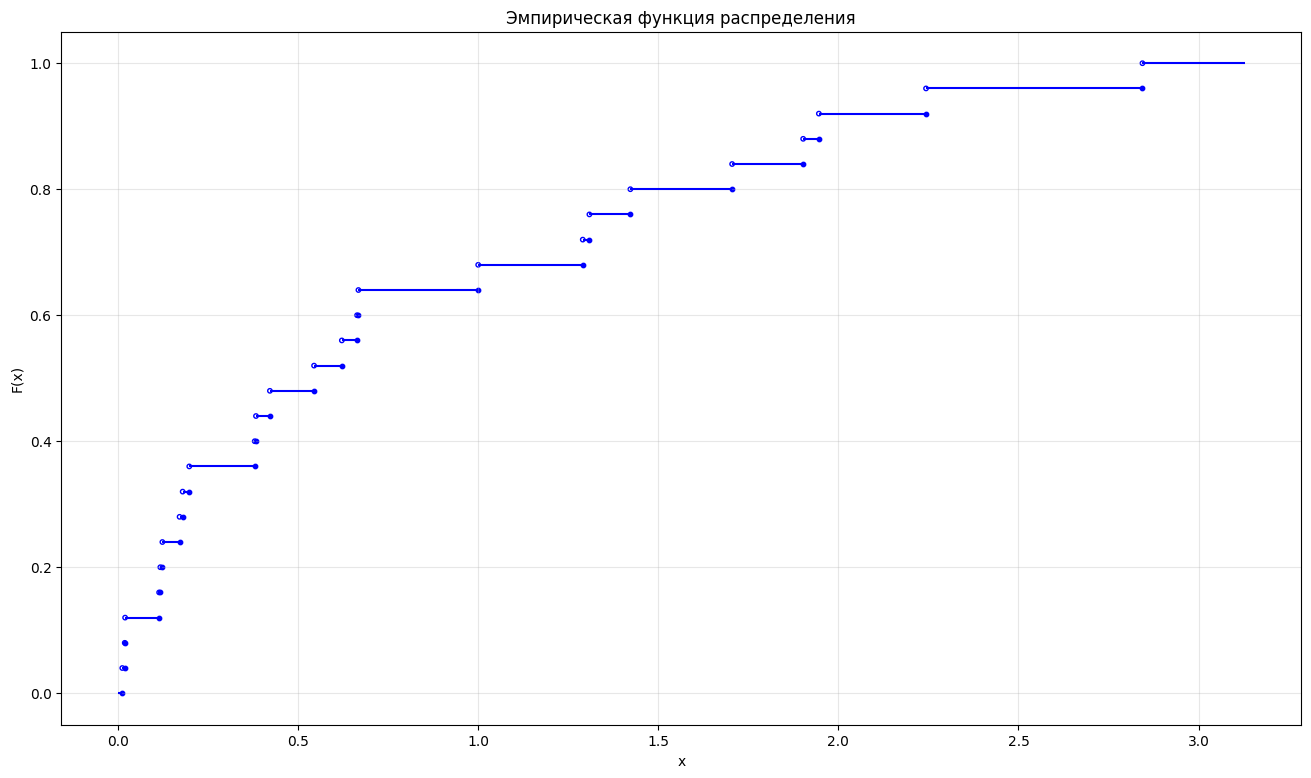

In [353]:
plt.figure(figsize=(16, 9))

x_ax = np.hstack((0, x_25))
y_ax0 = np.arange(0, n+1)/n
y_25 = np.arange(1, n+1)/n
y_ax1 = np.arange(0, n)/n


for i in range(len(x_ax)-1):
    plt.hlines(y=y_ax0[i], xmin=x_ax[i], xmax=x_ax[i+1], colors='b')    
plt.hlines(y=y_ax0[-1], xmin=x_ax[-1], xmax=x_ax[-1]*1.1, colors='b')

plt.scatter(x_25, y_25, marker='o', facecolors='none', edgecolors='b', s=10)
plt.scatter(x_25, y_ax1, marker="o", s=10, c='b')

plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Эмпирическая функция распределения')
plt.grid(True, alpha=0.3)
plt.show()

### Гистограмма

k = 5.643856189774724 => k = 6.0
deltai = 0.5016288411965959 => Ширина столбцов = 0.5


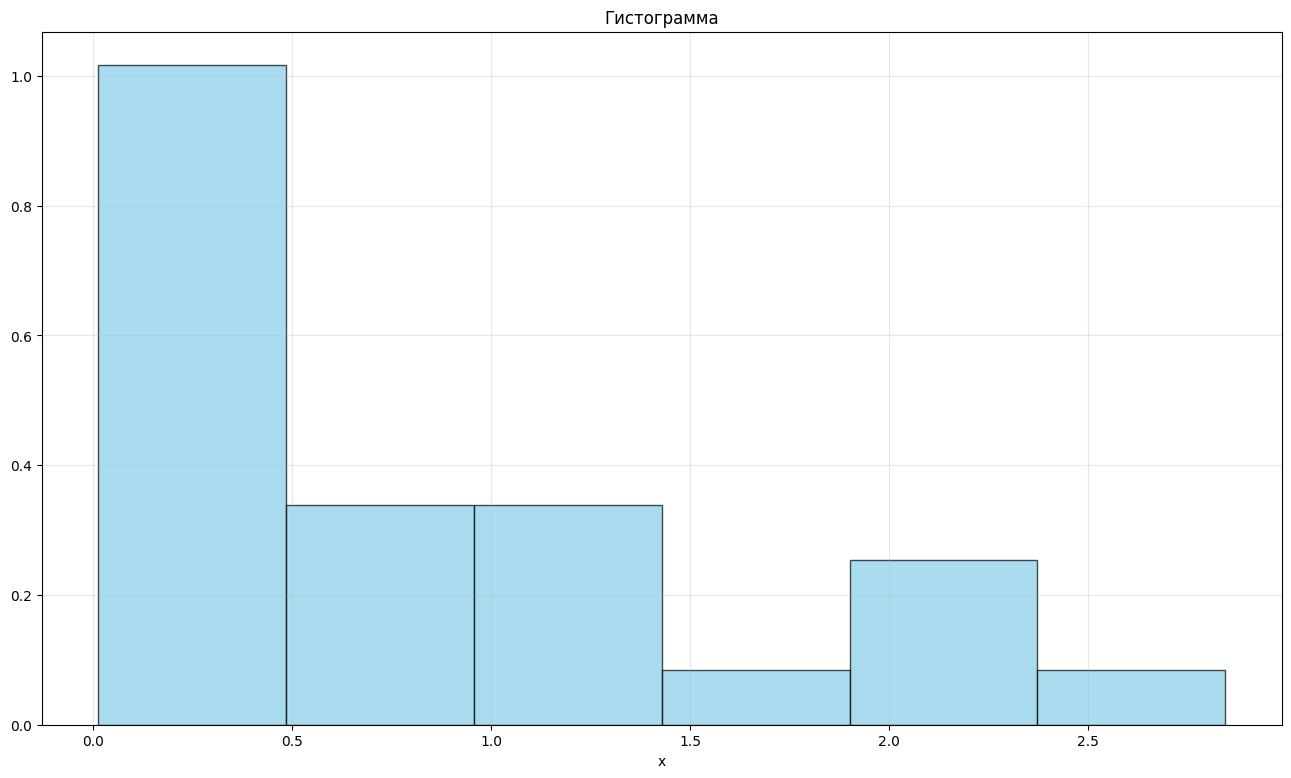


Детальный расчет:
Границы интервалов: [0.01 0.48 0.96 1.43 1.9  2.37 2.84]
Количество в интервалах (m): [12  4  4  1  3  1]
Доли (nu = m/n): [0.48 0.16 0.16 0.04 0.12 0.04]
Высоты (nu/deltai): [1.017 0.339 0.339 0.085 0.254 0.085]


In [354]:
k = 1 + math.log2(25)
print(f"k = {k} => k = {np.round(k)}")

deltai = l/k
print(f"deltai = {deltai} => Ширина столбцов = {np.round(deltai, 2)}")

k = int(np.round(k))
counts, bin_edges = np.histogram(x_25, bins=k)
nu = counts / n
bin_width = bin_edges[1] - bin_edges[0]
heights = nu / bin_width

plt.figure(figsize=(16, 9))
plt.hist(x_25, bins=k, density=True, color='skyblue', edgecolor='k', alpha=0.7)

plt.xlabel('x')
plt.title('Гистограмма')
plt.grid(True, alpha=0.3)
plt.show()

print("\nДетальный расчет:")
print(f"Границы интервалов: {np.round(bin_edges, 2)}")
print(f"Количество в интервалах (m): {counts}")
print(f"Доли (nu = m/n): {np.round(nu, 3)}")
print(f"Высоты (nu/deltai): {np.round(heights, 3)}")


### Boxplot

q1 = 0.17187112132080679
q2 = 0.5450782794641098
q3 = 1.3092017368664544
IQR = 1.1373306155456475
Нижняя граница усов = max(min, q1 - 1.5*IQR) = 0.013
Верхняя граница усов = min(max, q3 + 1.5*IQR) = 2.844


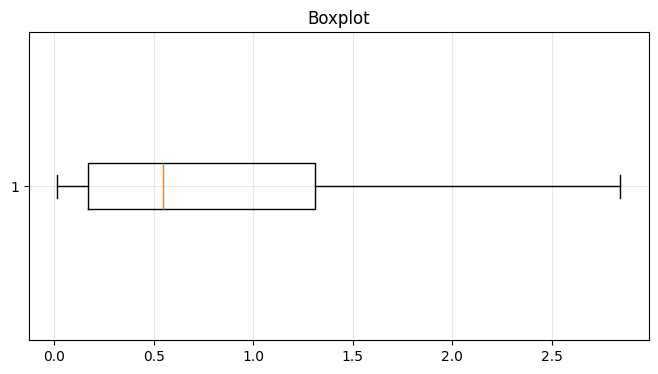

In [355]:
q1 = np.percentile(x_25, 25)
q2 = np.median(x_25)
q3 = np.percentile(x_25, 75)
IQR = q3 - q1

print(f"q1 = {q1}")
print(f"q2 = {q2}")
print(f"q3 = {q3}")
print(f"IQR = {IQR}")
print(f"Нижняя граница усов = max(min, q1 - 1.5*IQR) = {np.round(max(min(x_25), q1 - 1.5*IQR), 3)}")
print(f"Верхняя граница усов = min(max, q3 + 1.5*IQR) = {np.round(min(max(x_25), q3 + 1.5*IQR), 3)}")

plt.figure(figsize=(8, 4))
plt.boxplot(x_25, vert=False)
plt.title('Boxplot')
plt.grid(True, alpha=0.3)
plt.show()


## c)

По ЦПТ: среднее ~ N(1, 0.04) (см. c.jpg)

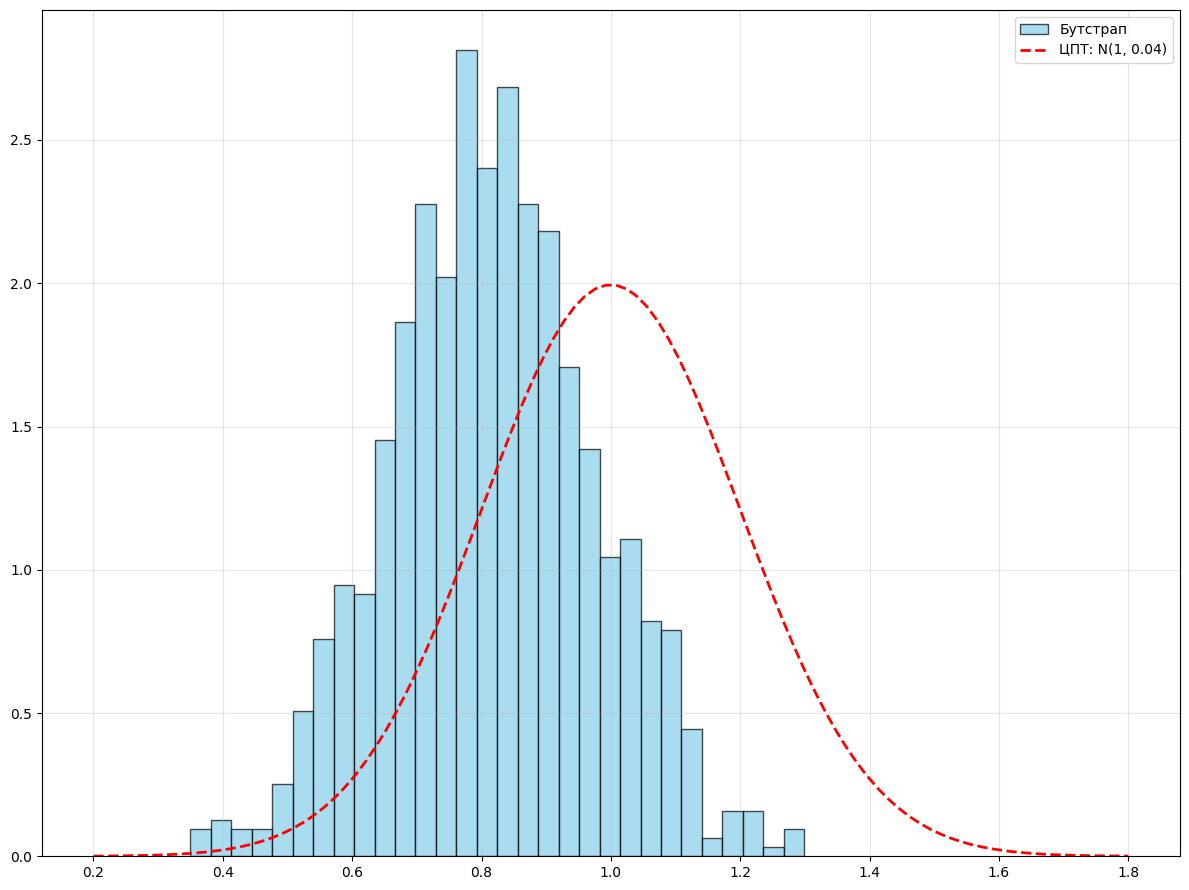


Исходное среднее: 0.8125
Среднее бутстраповских средних: 0.8164
Смещение: 0.0039


In [356]:
N = 1000
bootstrap_means = []

for _ in range(N):
    bootstrap_x_25 = np.random.choice(x_25, size=n, replace=True)
    bootstrap_means.append(np.mean(bootstrap_x_25))
bootstrap_means = np.array(bootstrap_means)

plt.figure(figsize=(12, 9))
plt.hist(bootstrap_means, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7, label='Бутстрап')

x = np.linspace(0.2, 1.8, 100)
cpt = stats.norm.pdf(x, loc=1, scale=0.2)
plt.plot(x, cpt, 'r--', linewidth=2, label='ЦПТ: N(1, 0.04)')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nИсходное среднее: {np.round(np.mean(x_25), 4)}")
print(f"Среднее бутстраповских средних: {np.round(np.mean(bootstrap_means), 4)}")
print(f"Смещение: {np.round(np.mean(bootstrap_means) - np.mean(x_25), 4)}")

## d)

* Примечание: `g` - коэффициент асимметрии

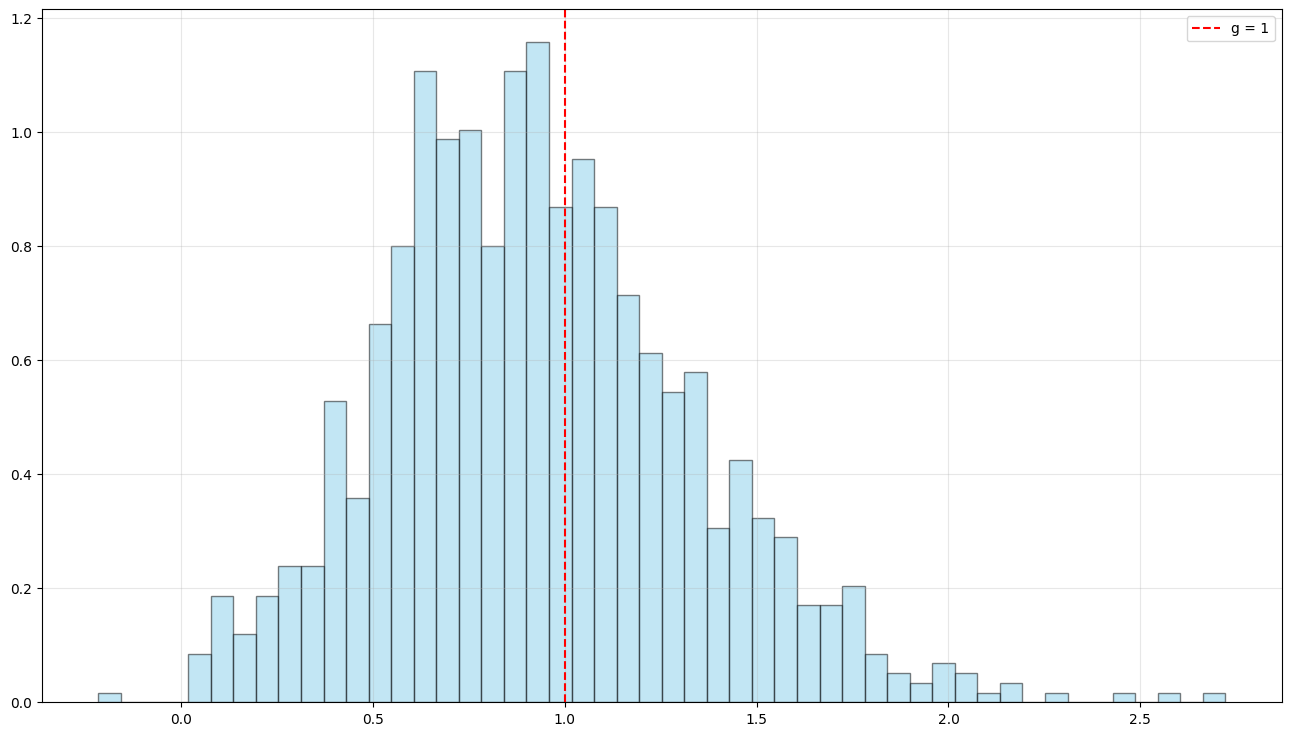

P(g < 1) = 0.603


In [ ]:
N = 1000
bootstrap_skewness = []

for _ in range(N):
    bootstrap_x_25 = np.random.choice(x_25, size=n, replace=True)
    bootstrap_skewness.append(stats.skew(bootstrap_x_25))
bootstrap_skewness = np.array(bootstrap_skewness)

P = np.mean(bootstrap_skewness < 1)

plt.figure(figsize=(16, 9))
plt.hist(bootstrap_skewness, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=1, color='r', linestyle='--',  label='g = 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"P(g < 1) = {P}")

## e)